### **This file performs 5 fold CV on the combined (RAVDESS, CREMA-D, TESS) dataset WITH data augmentation**

In [5]:
import pandas as pd
import numpy as np
import librosa

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [7]:
DATA_FILE = "../../datasets_combined_augmented_CV"

### Import files & extract relevant columns (audio file paths & labels)

In [8]:
train_df = pd.read_csv(f"{DATA_FILE}/train_split.csv")
test_df = pd.read_csv(f"{DATA_FILE}/test_split.csv")

train_files = train_df["file_path"].values
train_labels = train_df["Emotion"].values

test_files = test_df["file_path"].values
test_labels = test_df["Emotion"].values

# Define number of classes
num_classes = len(np.unique(train_labels))

### Define augmentation functions

In [9]:
def add_noise(y):
    noise_amp = 0.035 * np.random.uniform() * np.amax(y)
    return y + noise_amp * np.random.normal(size=y.shape)

def pitch_shift(y, sr):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=0.7)

def stretch(y):
    y = np.asarray(y, dtype=np.float32)
    return librosa.effects.time_stretch(y, rate=0.9)

### Define function to extract features from the audio files (paths)

In [10]:
def extract_features_from_files(file_list, augment=False):
    X_seq = []
    y_seq = []

    for file in file_list:
        y, sr = librosa.load("../../" + file, sr=44100)

        versions = [y]
        if augment:
            versions += [add_noise(y), pitch_shift(y, sr), stretch(y)]

        for audio in versions:
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=30)
            delta = librosa.feature.delta(mfcc)
            delta2 = librosa.feature.delta(mfcc, order=2)
            zcr = librosa.feature.zero_crossing_rate(audio)
            rmse = librosa.feature.rms(y=audio)

            features = np.vstack([mfcc, delta, delta2, zcr, rmse]).T
            X_seq.append(features)

            emotion = train_df.set_index("file_path").loc[file, "Emotion"]
            y_seq.append(emotion)

    X_seq = pad_sequences(X_seq, padding="post", dtype="float32")
    y_seq = np.array(y_seq)

    return X_seq, y_seq

### Define function to create model

In [11]:
import tensorflow as tf
from tensorflow.keras import layers as L

# function to re-initialize a fresh CNN–BiLSTM model for each fold.
def create_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        L.Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),

        L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),
        L.Dropout(0.2),

        L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),
        L.Dropout(0.2),

        L.Bidirectional(L.LSTM(128, return_sequences=False)),
        L.Dropout(0.3),

        L.Dense(256, activation='relu'),
        L.Dropout(0.3),
        L.Dense(128, activation='relu'),

        L.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

### Perform 5-fold CV

In [12]:
import time
from datetime import datetime

def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

In [6]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracies = []
all_histories = []
histories = []

fold = 1
for train_idx, val_idx in skf.split(train_files, train_labels):

    print("\n====================================================")
    print(f"[{now()}] ✅ STARTING FOLD {fold}")
    print("====================================================")

    fold_train_files = train_files[train_idx]
    fold_train_labels = train_labels[train_idx]

    fold_val_files = train_files[val_idx]
    fold_val_labels = train_labels[val_idx]

    # ---------------------------------------------------------
    # FEATURE EXTRACTION - TRAIN
    # ---------------------------------------------------------
    print(f"[{now()}] 🔄 Extracting TRAIN features (with augmentation)...")
    t0 = time.time()
    X_tr, y_tr = extract_features_from_files(fold_train_files, label_df=train_df, augment=True)
    print(f"[{now()}] ✅ Train features extracted. Time: {time.time() - t0:.2f}s")
    
    # ---------------------------------------------------------
    # FEATURE EXTRACTION - VALIDATION
    # ---------------------------------------------------------
    print(f"[{now()}] 🔄 Extracting VALIDATION features (NO augmentation)...")
    t0 = time.time()
    X_val, y_val = extract_features_from_files(fold_val_files, label_df=train_df, augment=False)
    print(f"[{now()}] ✅ Validation features extracted. Time: {time.time() - t0:.2f}s")

    # ---------------------------------------------------------
    # ONE-HOT ENCODING
    # ---------------------------------------------------------
    print(f"[{now()}] 🔄 One-hot encoding labels...")
    y_tr_cat = to_categorical(y_tr - 1, num_classes)
    y_val_cat = to_categorical(y_val - 1, num_classes)
    print(f"[{now()}] ✅ One-hot encoding done.")

    # -----------------------------------------------------------
    # CLASS WEIGHTS
    # -----------------------------------------------------------
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(enumerate(cw))

    # ---------------------------------------------------------
    # NORMALIZATION
    # ---------------------------------------------------------
    print(f"[{now()}] 🔄 Normalizing features for this fold...")
    t0 = time.time()
    mean = X_tr.mean(axis=(0, 1), keepdims=True)
    std = X_tr.std(axis=(0, 1), keepdims=True) + 1e-8
    X_tr = (X_tr - mean) / std
    X_val = (X_val - mean) / std
    print(f"[{now()}] ✅ Normalization done. Time: {time.time() - t0:.2f}s")

    # ---------------------------------------------------------
    # MODEL BUILDING
    # ---------------------------------------------------------
    print(f"[{now()}] 🔄 Building model...")
    t0 = time.time()
    model = create_model(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        num_classes=num_classes
    )
    print(f"[{now()}] ✅ Model built. Time: {time.time() - t0:.2f}s")

    # -----------------------------------------------------------
    # CALLBACKS
    # -----------------------------------------------------------
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
        ModelCheckpoint(
            filepath=f"cnn_lstm_aug_best_model_fold_{fold}.keras",
            monitor="val_accuracy",
            save_best_only=True
        )
    ]

    # ---------------------------------------------------------
    # TRAINING
    # ---------------------------------------------------------
    print(f"[{now()}] 🚀 Training model for FOLD {fold}...")
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr_cat,
        validation_data=(X_val, y_val_cat),
        batch_size=64,
        class_weight=class_weights,
        epochs=50,
        verbose=1,
        callbacks=callbacks
    )
    print(f"[{now()}] ✅ Training complete for FOLD {fold}. Time: {time.time() - t0:.2f}s")

    print("====================================================")
    print(f"[{now()}] ✅ FOLD {fold} FINISHED")
    
    # -----------------------------------------------------------
    # RECORD BEST VAL ACCURACY
    # -----------------------------------------------------------
    best_acc = max(history.history["val_accuracy"])
    cv_accuracies.append(best_acc)
    all_histories.append(history.history)
    histories.append(history)

    print(f"[{now()}] ✅ Fold {fold} Best Val Accuracy: {best_acc:.4f}")
    print("====================================================\n")

    fold += 1


NameError: name 'train_files' is not defined

### CV Summary

In [13]:
print("\n==============================================================")
print(f"✅ CROSS-VALIDATION COMPLETE")
print(f"✅ Mean Val Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print("==============================================================")


✅ CROSS-VALIDATION COMPLETE
✅ Mean Val Accuracy: 0.7250 ± 0.0104


### Plot results

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Determine max number of epochs across folds ---
max_epochs = max(len(h.history['accuracy']) for h in histories)

# --- Step 2: Create NaN-padded arrays ---
train_accs = np.full((len(histories), max_epochs), np.nan)
val_accs   = np.full((len(histories), max_epochs), np.nan)
train_loss = np.full((len(histories), max_epochs), np.nan)
val_loss   = np.full((len(histories), max_epochs), np.nan)

# --- Step 3: Fill with actual values (rest remain NaN) ---
for i, h in enumerate(histories):
    L = len(h.history['accuracy'])

    train_accs[i, :L] = h.history['accuracy']
    val_accs[i, :L]   = h.history['val_accuracy']
    train_loss[i, :L] = h.history['loss']
    val_loss[i, :L]   = h.history['val_loss']

# --- Step 4: Compute nan-safe mean & std ---
mean_train_acc = np.nanmean(train_accs, axis=0)
std_train_acc  = np.nanstd(train_accs, axis=0)

mean_val_acc = np.nanmean(val_accs, axis=0)
std_val_acc  = np.nanstd(val_accs, axis=0)

mean_train_loss = np.nanmean(train_loss, axis=0)
std_train_loss  = np.nanstd(train_loss, axis=0)

mean_val_loss = np.nanmean(val_loss, axis=0)
std_val_loss  = np.nanstd(val_loss, axis=0)

epochs = np.arange(max_epochs)

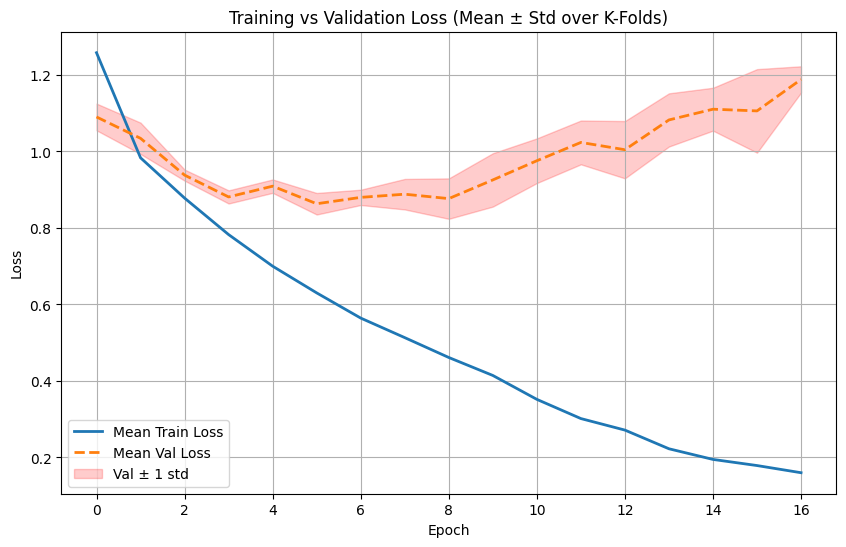

In [15]:
plt.figure(figsize=(10,6))

# --- Loss curves ---
plt.plot(epochs, mean_train_loss, label='Mean Train Loss', linewidth=2)
plt.plot(epochs, mean_val_loss, label='Mean Val Loss', linestyle='--', linewidth=2)

# --- Shaded standard deviation ---
plt.fill_between(epochs,
                 mean_val_loss - std_val_loss,
                 mean_val_loss + std_val_loss,
                 alpha=0.20,
                 color='red',
                 label='Val ± 1 std')

plt.title('Training vs Validation Loss (Mean ± Std over K-Folds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

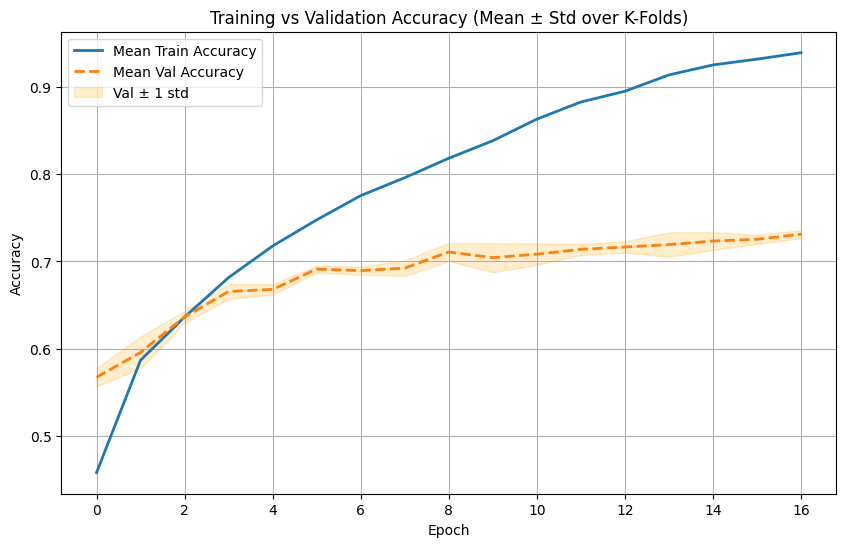

In [16]:
plt.figure(figsize=(10,6))

# --- Accuracy curves ---
plt.plot(epochs, mean_train_acc, label='Mean Train Accuracy', linewidth=2)
plt.plot(epochs, mean_val_acc, label='Mean Val Accuracy', linestyle='--', linewidth=2)

# --- Shaded standard deviation ---
plt.fill_between(epochs,
                 mean_val_acc - std_val_acc,
                 mean_val_acc + std_val_acc,
                 alpha=0.20,
                 color='orange',
                 label='Val ± 1 std')

plt.title('Training vs Validation Accuracy (Mean ± Std over K-Folds)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Evaluate model

#### Train best model

In [17]:
import os
import numpy as np
import librosa
from tensorflow.keras.preprocessing.sequence import pad_sequences

def extract_features_from_files(file_list, label_df, augment=False):
    X_seq = []
    y_seq = []

    # Build lookup once (much faster than set_index every time)
    label_map = label_df.set_index("file_path")["Emotion"].to_dict()

    for file in file_list:
        # If you need ../../, keep it here
        full_path = "../../" + file

        y, sr = librosa.load(full_path, sr=44100)

        versions = [y]
        if augment:
            versions += [add_noise(y), pitch_shift(y, sr), stretch(y)]

        for audio in versions:
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=30)
            delta = librosa.feature.delta(mfcc)
            delta2 = librosa.feature.delta(mfcc, order=2)
            zcr = librosa.feature.zero_crossing_rate(audio)
            rmse = librosa.feature.rms(y=audio)

            features = np.vstack([mfcc, delta, delta2, zcr, rmse]).T
            X_seq.append(features)

            # ✅ use the correct dataframe’s label
            emotion = label_map[file]
            y_seq.append(emotion)

    X_seq = pad_sequences(X_seq, padding="post", dtype="float32")
    y_seq = np.array(y_seq)

    return X_seq, y_seq


In [18]:
# ============================
# FULL TRAIN + TEST FEATURES
# ============================
print(f"[{now()}] 🔄 Extracting FULL TRAIN features (with augmentation)...")
t0 = time.time()
X_train, y_train = extract_features_from_files(train_files, label_df=train_df, augment=True)
print(f"[{now()}] ✅ Full train features extracted. Time: {time.time() - t0:.2f}s")

print(f"[{now()}] 🔄 Extracting TEST features (NO augmentation)...")
t0 = time.time()
X_test, y_test = extract_features_from_files(test_files, label_df=test_df, augment=False)
print(f"[{now()}] ✅ Test features extracted. Time: {time.time() - t0:.2f}s")



# ============================
# ONE-HOT ENCODING
# ============================
print(f"[{now()}] 🔄 One-hot encoding FULL TRAIN + TEST labels...")
y_train_full_cat = to_categorical(y_train - 1, num_classes)
y_test_cat = to_categorical(y_test - 1, num_classes)
print(f"[{now()}] ✅ One-hot encoding done.")


# ============================
# CLASS WEIGHTS (FULL TRAIN)
# ============================
cw_train = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_train = dict(enumerate(cw_train))


# ============================
# NORMALIZATION
# ============================
print(f"[{now()}] 🔄 Normalizing FULL TRAIN + TEST features...")
t0 = time.time()
mean_train = X_train.mean(axis=(0, 1), keepdims=True)
std_train = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train
print(f"[{now()}] ✅ Normalization done. Time: {time.time() - t0:.2f}s")


# ============================
# SAVE FOR FUTURE USE
# ============================
np.save("X_test_norm.npy", X_test)
np.save("y_test.npy",      y_test)
np.save("mean_train.npy",  mean_train)
np.save("std_train.npy",   std_train)

[2025-11-24 17:06:08] 🔄 Extracting FULL TRAIN features (with augmentation)...


KeyboardInterrupt: 

In [23]:
# ============================
# FINAL MODEL
# ============================
print(f"[{now()}] 🔄 Building FINAL model...")
model_final = create_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=num_classes
)
print(f"[{now()}] ✅ Final model built.")

callbacks_final = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
    ModelCheckpoint(
        filepath="cnn_lstm_aug_best_final_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

print(f"[{now()}] 🚀 Training FINAL model on FULL TRAIN...")
t0 = time.time()
history_final = model_final.fit(
    X_train, y_train_full_cat,
    validation_split=0.1,     # takes 10% of train as val for early stopping
    batch_size=64,
    class_weight=class_weights_train,
    epochs=50,
    verbose=1,
    callbacks=callbacks_final
)
print(f"[{now()}] ✅ FINAL training complete. Time: {time.time() - t0:.2f}s")

[2025-11-23 12:27:30] 🔄 Building FINAL model...


c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2025-11-23 12:27:31] ✅ Final model built.
[2025-11-23 12:27:31] 🚀 Training FINAL model on FULL TRAIN...
Epoch 1/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 263s 525ms/step - accuracy: 0.4800 - loss: 1.2142 - val_accuracy: 0.5810 - val_loss: 1.0853 - learning_rate: 0.0010
Epoch 2/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 254s 529ms/step - accuracy: 0.6079 - loss: 0.9394 - val_accuracy: 0.6097 - val_loss: 0.9984 - learning_rate: 0.0010
Epoch 3/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 256s 532ms/step - accuracy: 0.6658 - loss: 0.8208 - val_accuracy: 0.6432 - val_loss: 0.9136 - learning_rate: 0.0010
Epoch 4/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 251s 523ms/step - accuracy: 0.7076 - loss: 0.7250 - val_accuracy: 0.6587 - val_loss: 0.8821 - learning_rate: 0.0010
Epoch 5/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 251s 523ms/step - accuracy: 0.7408 - loss: 0.6464 - val_accuracy: 0.6705 - val_loss: 0.9041 - learning_rate: 0.0010
Epoch 6/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 251s 524ms/step - accuracy: 0.7722 - loss: 0.5752 - val_accuracy: 0.6802 - 

#### Evaluate on test set

In [14]:
from tensorflow.keras.models import load_model

num_classes = 7

# 1. Load model
model_final = load_model("cnn_lstm_aug_best_final_model.keras")

# 2. Load preprocessed test data
X_test = np.load("X_test_norm.npy")
y_test = np.load("y_test.npy")

# 3. One-hot encode
y_test_cat = to_categorical(y_test - 1, num_classes)

In [15]:
# ============================
# TEST EVALUATION
# ============================
print(f"[{now()}] 📊 Evaluating on TEST set...")
test_loss, test_acc = model_final.evaluate(X_test, y_test_cat, batch_size=64, verbose=1)
print(f"[{now()}] ✅ Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


[2025-11-24 17:04:24] 📊 Evaluating on TEST set...


NameError: name 'X_test' is not defined

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

y_proba = model_final.predict(X_test)
y_pred_classes = np.argmax(y_proba, axis=1) + 1   # +1 because you subtracted 1 earlier

print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step
              precision    recall  f1-score   support

           1       0.73      0.80      0.76       324
           2       0.72      0.62      0.67       338
           3       0.66      0.66      0.66       337
           4       0.80      0.85      0.82       338
           5       0.65      0.62      0.64       338
           6       0.71      0.72      0.71       337
           7       0.91      0.96      0.93       118

    accuracy                           0.72      2130
   macro avg       0.74      0.75      0.74      2130
weighted avg       0.72      0.72      0.72      2130

[[260  24  15   4   5  16   0]
 [ 19 211   9  28  55  11   5]
 [ 45   8 221   3  27  33   0]
 [  5  17   0 287   9  19   1]
 [ 11  18  62  15 209  19   4]
 [ 15  15  26  24  14 242   1]
 [  2   1   0   0   1   1 113]]


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

emotion_labels = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

NameError: name 'cm' is not defined

<Figure size 1000x800 with 0 Axes>

#### Per class accuracy heatmap

In [ ]:
class_names = [f"Class {i}" for i in range(1, num_classes+1)]

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 4))
sns.heatmap(per_class_accuracy.reshape(1, -1), annot=True, cmap="Greens", fmt=".2f",
            xticklabels=class_names, yticklabels=["Accuracy"])
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.show()

#### ROC Curves

In [ ]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert to one-hot (binarized)
y_test_bin = label_binarize(y_test, classes=np.arange(1, num_classes+1))

plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
